In [1]:
import pandas as pd
import joblib

models = joblib.load('../data/processed/baseline_models.pkl')
train_X, val_X, train_y, val_y = joblib.load('../data/processed/train_val_split.pkl')

sample_vs_ph = pd.DataFrame({
    'BRFSS_sample': [
        train_X['Smoker'].mean(),
        train_X['HighBP'].mean(),
        train_X['has_diabetes'].mean(),
        (train_X['bmi_cat_ph'] == 3).mean()
    ],
    'PH_published': [0.20, 0.33, 0.063, 0.398]
}, index=['Smoker', 'HighBP', 'Diabetes', 'Obese']) # Sample comparison vs published PH data

sample_vs_ph

,BRFSS_sample,PH_published
Smoker,0.464994,0.200
HighBP,0.453972,0.330
Diabetes,0.172594,0.063
Obese,0.587480,0.398


In [2]:
# Prior-shift correction function (standard Bayes-based formula)

def correct_prior_shift(p, source_prior, target_prior):
    source_odds = p / (1 - p)
    correction = (target_prior / (1 - target_prior)) / (source_prior / (1 - source_prior))
    target_odds = source_odds * correction
    return target_odds / (1 + target_odds)

In [3]:
# Undo class_weight='balanced' distortion

raw_probs = models['LightGBM'].predict_proba(val_X)[:, 1]

true_train_prevalence = train_y.mean()
brfss_calibrated_probs = correct_prior_shift(raw_probs, 0.5, true_train_prevalence)

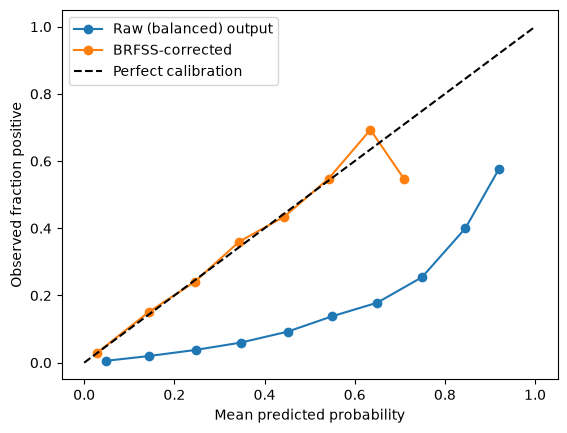

In [4]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

frac_before, pred_before = calibration_curve(val_y, raw_probs, n_bins=10)
frac_after, pred_after = calibration_curve(val_y, brfss_calibrated_probs, n_bins=10)

plt.plot(pred_before, frac_before, marker='o', label='Raw (balanced) output')
plt.plot(pred_after, frac_after, marker='o', label='BRFSS-corrected')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed fraction positive')
plt.legend()
plt.show()

In [5]:
# Shift towards PH target

PH_CVD_PREVALENCE = 0.167

ph_calibrated_probs = correct_prior_shift(brfss_calibrated_probs, true_train_prevalence, PH_CVD_PREVALENCE)

print(brfss_calibrated_probs.mean(), ph_calibrated_probs.mean())

0.1009316584996997 0.14918013755632042


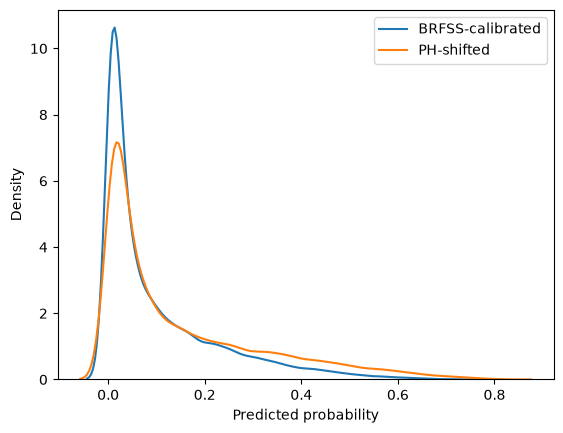

In [6]:
import seaborn as sns

sns.kdeplot(brfss_calibrated_probs, label='BRFSS-calibrated')
sns.kdeplot(ph_calibrated_probs, label='PH-shifted')
plt.xlabel('Predicted probability')
plt.legend()
plt.show()

In [8]:
calibration_results = pd.DataFrame({
    'true_label': val_y.values,
    'raw_prob': raw_probs,
    'brfss_calibrated_prob': brfss_calibrated_probs,
    'ph_calibrated_prob': ph_calibrated_probs
})

calibration_results.to_csv('../data/processed/ph_calibration_results.csv', index=False)